# Neural Particle Automata — Growing a Morphology

> ⚠️ **This notebook requires a GPU.** In Colab: **Runtime → Change runtime type → Hardware accelerator → GPU**. The perception operators are custom CUDA kernels and will not run on CPU.

### 1. Clone the repository

In [1]:
!git clone https://github.com/TheDevilWillBeBee/NPA.git
%cd NPA

Cloning into 'NPA'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 68 (delta 8), reused 65 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 453.26 KiB | 2.48 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/NPA


### 2. Build the CUDA kernels

In [2]:
!pip install -q nanobind
%cd sphops
!bash build.sh
# !python3 test.py
%cd ..

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.5/249.5 kB 8.2 MB/s eta 0:00:00
/content/NPA/sphops
CMake Warning:
  Ignoring extra path from command line:

   "/content/NPA/sphops/build/DCMAKE_BUILD_TYPE=Release"


-- The CXX compiler identification is GNU 11.4.0
-- The CUDA compiler identification is NVIDIA 12.8.93 with host compiler GNU 11.4.0
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Detecting CUDA compiler ABI info
-- Detecting CUDA compiler ABI info - done
-- Check for working CUDA compiler: /usr/local/cuda/bin/nvcc - skipped
-- Detecting CUDA compile features
-- Detecting CUDA compile features - done
-- Found CUDAToolkit: /usr/local/cuda/targets/x86_64-linux/include (found version "12.8.93")
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE
--

### 3. Imports and device setup

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

torch.set_default_device('cuda')
device = torch.device('cuda')

from models.npa import NPA, Pool, step_euler
from sphops import HashGrid
from losses import Loss
from losses.utils import get_color_from_state
from utils import loader
from commons import geometry

print('Torch:', torch.__version__, '| CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128 | CUDA available: True
GPU: Tesla T4


### 4. Load the target image

The image resolution is chosen adaptively so that the particle count is close to `NUM_POINTS` (≈ 4096).

Adaptive image size: [95, 95]
Number of target points: (4101, 2)


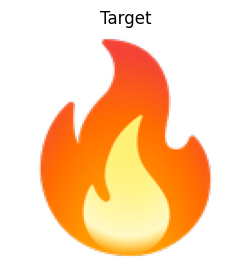

In [5]:
#@title {vertical-output: true}
TARGET      = '🔥'              # URL, path, or a single emoji
AABB        = [-1, 1, -1, 1]    # minx, maxx, miny, maxy
THRESHOLD   = 0.05              # alpha threshold for "solid" pixels
NUM_POINTS  = 4096              # target ~ this many particles
IMAGE_SIZE  = None              # None -> pick resolution adaptively from NUM_POINTS

@torch.no_grad()
def get_target(path, aabb, threshold, num_points, image_size=None):
    def adaptive_size(num_points):
        H = 128
        for _ in range(5):
            img = loader.load_target_image(path, size=[H, H])
            nonzero = int(np.sum(img[..., 3] >= threshold))
            H = int(np.round(np.sqrt(num_points / nonzero) * H))
        return H

    if image_size is None:
        H = adaptive_size(num_points)
        image_size = [H, H]
        print('Adaptive image size:', image_size)

    pixel_size = (aabb[1] - aabb[0]) / image_size[0]
    aabb_min = aabb[0::2]
    aabb_max = aabb[1::2]

    target_image = loader.load_target_image(path, size=image_size)
    target_image = torch.from_numpy(
        target_image.transpose(1, 0, 2)[:, ::-1, :].copy()
    ).to(device)

    target_pos = geometry.grange(
        target_image.shape[:2],
        aabb_min,
        [mx - mn for mn, mx in zip(aabb_min, aabb_max)],
        device=device,
    )

    target_alpha = target_image[..., 3]
    nonzero = target_alpha > threshold
    target_colors = target_image[nonzero][..., :3]
    target_pos = target_pos[nonzero]
    print('Number of target points:', tuple(target_pos.shape))

    return {
        'image': target_image.to(torch.float32),
        'positions': target_pos.to(torch.float32),
        'colors': target_colors.to(torch.float32),
        'pixel_size': pixel_size,
    }

target = get_target(TARGET, AABB, THRESHOLD, NUM_POINTS, IMAGE_SIZE)

plt.figure(figsize=(3, 3))
plt.imshow(loader.load_target_image(TARGET, size=[128, 128]))
plt.title(f'Target')
plt.axis('off')
plt.show()

### 5. Initialize the model, loss, hash grid and pool

Set `GRAFT_PATH` to a checkpoint (e.g. `data/pretrained/lizard.pth`) to start from a pretrained
model, or leave it `None` to train from scratch.

In [37]:
spatial_dims  = 2
num_particles = 4096
batch_size    = 4

# --- HashGrid config (configs/growing.yaml: hashgrid) ---
hashgrid_kwargs = dict(
    dim=2,
    boundary='clamped',
    mode='grid',
    grid_size=[16, 16],
    eps=0.1,
    max_particles_per_block=32,
)
grid      = HashGrid(num_particles=num_particles, batch_size=batch_size, **hashgrid_kwargs)
grid_test = HashGrid(num_particles=num_particles, batch_size=1,          **hashgrid_kwargs)

# --- Model (configs/growing.yaml: npa.kwargs) ---
model = NPA(
    spatial_dims=spatial_dims,
    state_dims=16,
    hidden_dims=128,
    eps0=0.1,
    alpha=0.5,
).to(device)
state_dims = model.state_dims

# --- Optional grafting from a pretrained checkpoint ---
GRAFT_PATH = "data/pretrained/lizard.pth"  # e.g. 'data/pretrained/lizard.pth'
if GRAFT_PATH is not None:
    checkpoint = torch.load(GRAFT_PATH, map_location=device)
    if model.eps0.item() != float(checkpoint['eps0']):
        print('Warning: pretrained model has a different eps0.')
    if model.alpha.item() != float(checkpoint['alpha']):
        print('Warning: pretrained model has a different alpha.')
    model.load_state_dict(checkpoint)
    print(f'Grafted model from {GRAFT_PATH}')
else:
    print('Training from scratch (random initialization).')

# --- Loss (configs/growing.yaml: train.loss) ---
loss_fn = Loss(
    target,
    splat_loss_weight=2.0,
    displacement_regularizer_weight=0.01,
    overflow_regularizer_weight=100.0,
    bound_regularizer_weight=100.0,
    splat_loss_kwargs=dict(
        density_loss_weight=1.0,
        color_loss_weight=5.0,
        lpips_loss_weight=0.0,
        grid_size=256,
        sigma=1.0,
        lo=-1.0,
        hi=1.0,
        center=True,
    ),
)

# --- Pool (configs/growing.yaml: pool) ---
pool = Pool(
    state_dims=state_dims,
    spatial_dims=spatial_dims,
    pool_size=512,
    num_particles=num_particles,
    sigma=0.2,
    noise_level=0.0,
    seed_mode='uniform_circle',
    random_seed=42,
    device=device,
)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params}')

Grafted model from data/pretrained/lizard.pth
Model parameters: 10880


### 6. Training loop

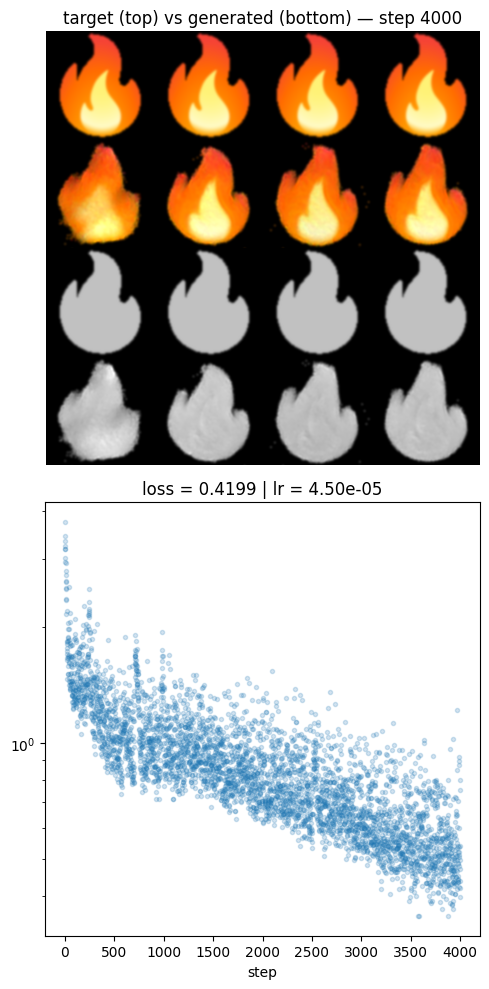

In [38]:
#@title {vertical-output: true}
EPOCHS              = 4000
step_range          = (32, 96)   # random #update-steps per training step
inject_seed_interval = 16
summary_interval    = 10
noise_std           = 0.0
brush_size          = 0.1        # radius of the erased region (0 to disable)
update_prob         = 0.5        # stochastic per-particle update (async)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[1500, 3000], gamma=0.3
)

loss_log = []
for epoch in range(EPOCHS + 1):
    replace = (epoch % inject_seed_interval) == 0

    with torch.no_grad():
        x, s, idx = pool.sample(batch_size, replace_seed=replace)

        # Erase a random circular region of the state so the model learns to regenerate.
        if brush_size > 0.0:
            B, N, D = x.shape
            random_point = torch.randint(N, (B,), device=device)
            center = x[torch.arange(B), random_point]            # [B, D]
            distances = torch.norm(x - center.unsqueeze(1), dim=-1)  # [B, N]
            mask = distances < brush_size
            s = s.masked_fill(mask.unsqueeze(-1), 0.0)

    steps = np.random.randint(*step_range)
    sum_dx = 0.0
    for _ in range(steps):
        x, s, stats = step_euler(
            model, x, s, grid,
            update_prob=update_prob, intermediate=True, noise_std=noise_std,
        )
        sum_dx += stats['dx_norm']
    x = grid.wrap_positions(x)

    out = model.decode(s)
    ctx = {'positions': x, 'states': s, 'outputs': out, 'sum_dx': sum_dx}

    summary = (epoch % summary_interval) == 0
    loss, loss_info = loss_fn(ctx, return_info=summary, return_summary=summary)

    if torch.isnan(loss) or torch.isinf(loss):
        raise ValueError('Loss is NaN or Inf. Stopping training.')

    loss.backward()
    model.normalize_grads()      # per-parameter gradient normalization
    optimizer.step()
    optimizer.zero_grad()
    scheduler.step()

    with torch.no_grad():
        pool.update(x, s, idx)   # write the evolved rollouts back to the pool
        loss_log.append(loss.item())

        if summary:
            summary_img = np.array(loss_info['splat_loss']['summary']['image'])
            clear_output(wait=True)
            fig, axes = plt.subplots(2, 1, figsize=(5, 10))
            axes[0].imshow(summary_img)
            axes[0].set_title(f'target (top) vs generated (bottom) — step {epoch}')
            axes[0].axis('off')
            axes[1].plot(loss_log, '.', alpha=0.2)
            axes[1].set_yscale('log')
            axes[1].set_xlabel('step')
            axes[1].set_title(
                f'loss = {loss.item():.4f} | lr = {scheduler.get_last_lr()[0]:.2e}'
            )
            plt.tight_layout()
            plt.show()

### 7. Visualize the learned dynamics

In [40]:
#@title {vertical-output: true}
from utils.video import VideoWriter
from utils.splatting import splat_particles
from tqdm.auto import trange
from IPython.display import Video

splat = loss_fn.loss_modules['splat_loss']

@torch.no_grad()
def render_rgb(x, s):
    # Center the cloud on the target and splat to an RGB image.
    color = s[..., -3:] + 0.5
    color_density = splat_particles(x[0], color[0], img_size=256, sigma=0.5, y_up=True)
    img_color = color_density[..., :3]
    return img_color.clamp(0.0, 1.0).cpu().numpy()

with VideoWriter('growing.mp4', fps=30.0) as vid, torch.no_grad():
    x, s = pool.seed_generator(1)          # a single fresh seed
    for k in trange(300):
        step_n = min(2 ** (k // 30), 8)
        for _ in range(step_n):
            x, s, _ = step_euler(model, x, s, grid_test)
        x = grid_test.wrap_positions(x)
        img = render_rgb(x, s)
        vid.add(img)      # upscale 2x for display

Video('growing.mp4', embed=True, width=512)

  0%|          | 0/300 [00:00<?, ?it/s]